# 01 — Data Cleaning & Exploratory Data Analysis

**Berlin Food Delivery ETA & Ops Intelligence Platform**

Source data: [Food Delivery Dataset (Kaggle)](https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset) — 45,593 training rows / 11,399 test rows of real food-delivery orders (restaurant/delivery coordinates, weather, traffic, delivery-partner attributes, and delivery time).

This notebook covers the raw data's quirks and the EDA that motivated every downstream module in this project.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline
pd.set_option('display.max_columns', 40)


## Load raw data and inspect known quirks

In [2]:
raw = pd.read_csv('../data/train_raw.csv')
raw.head(3)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26


In [3]:
raw.dtypes

ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object

The raw export has several issues typical of scraped/exported operational data:
- `Time_taken(min)` (the target) is stored as text: `"(min) 24"`
- `Delivery_person_Age`, `Delivery_person_Ratings`, `multiple_deliveries` are numeric but typed as strings
- Categorical columns carry stray whitespace and literal `"NaN "` strings instead of real nulls
- `Weatherconditions` is prefixed with the word `"conditions "`

All of this is handled by `src/data_prep.clean_raw()`.

In [4]:
from data_prep import clean_raw, add_core_features

train = clean_raw('../data/train_raw.csv', is_train=True)
train = add_core_features(train)
print(train.shape)
train[['distance_km','prep_time_min','traffic_ordinal','Time_taken(min)']].describe()

(45593, 30)


,distance_km,prep_time_min,traffic_ordinal,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,9.926962,9.989801,1.364815,26.294607
std,5.916366,4.009169,1.247976,9.383806
min,1.465067,5.000000,0.000000,10.000000
25%,4.663493,5.000000,0.000000,19.000000
50%,9.264281,10.000000,1.000000,26.000000
75%,13.763977,15.000000,3.000000,32.000000
max,30.000000,15.000000,3.000000,54.000000


## Target distribution

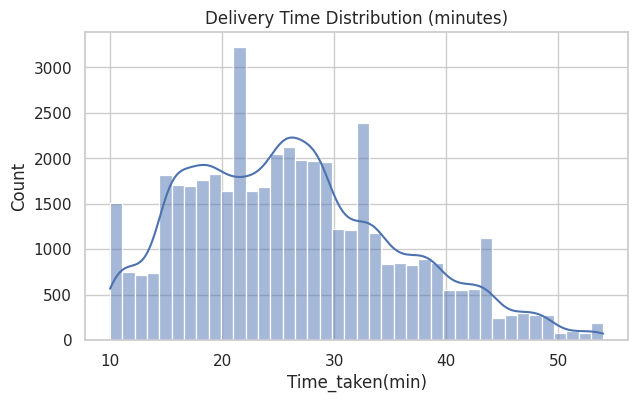

In [5]:
plt.figure(figsize=(7,4))
sns.histplot(train['Time_taken(min)'], bins=40, kde=True)
plt.title('Delivery Time Distribution (minutes)')
plt.show()

## Delivery time vs. distance and traffic

Distance and traffic density are the two structural drivers of delivery time — this is what the ETA model in notebook 03 leans on most heavily.

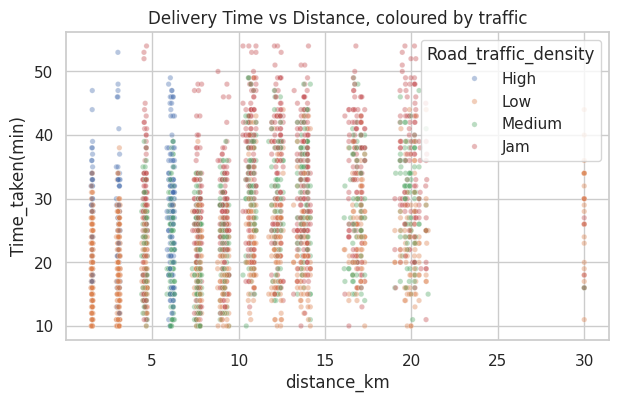

In [6]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=train.sample(3000, random_state=1), x='distance_km', y='Time_taken(min)',
                hue='Road_traffic_density', alpha=0.4, s=15)
plt.title('Delivery Time vs Distance, coloured by traffic')
plt.show()

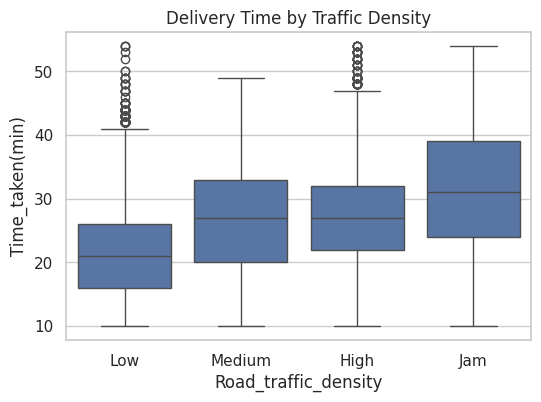

In [7]:
plt.figure(figsize=(6,4))
order = ['Low','Medium','High','Jam']
sns.boxplot(data=train, x='Road_traffic_density', y='Time_taken(min)', order=order)
plt.title('Delivery Time by Traffic Density')
plt.show()

## Small-sample caveats

`Semi-Urban` city type and `Festival` days are under-represented — any strong-looking pattern in those slices should be treated as low-confidence, not a headline finding.

In [8]:
train['City'].value_counts(), train['Festival'].value_counts()

(City
 Metropolitian    35293
 Urban            10136
 Semi-Urban         164
 Name: count, dtype: int64,
 Festival
 No     44697
 Yes      896
 Name: count, dtype: int64)

## Correlation heatmap (numeric features)

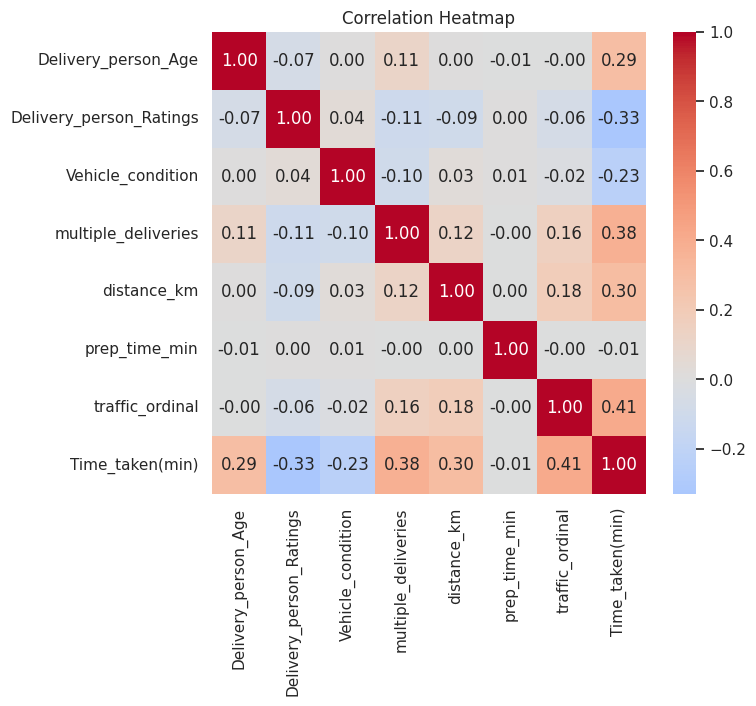

In [9]:
num_cols = ['Delivery_person_Age','Delivery_person_Ratings','Vehicle_condition',
            'multiple_deliveries','distance_km','prep_time_min','traffic_ordinal','Time_taken(min)']
plt.figure(figsize=(7,6))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

**Takeaways feeding the rest of the project:**
- Distance and traffic density are the dominant ETA drivers → core regression model (notebook 03)
- Order volume varies meaningfully by day → demand forecasting (notebook 04)
- Delivery-partner rating and experience vary widely → recommendation/matching engine (notebook 05)
- A small number of orders have physically implausible speed/time combinations → fraud/anomaly detection (notebook 06)
- Multiple partners and orders are live at once → batch assignment optimization (notebook 07)